In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import os
from tqdm import tqdm
from sklearn.model_selection import KFold
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

tqdm.pandas()

SAVE_DIR = "../../output/redundancy/"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
df_low_scorer = pd.read_csv("../../output/model/run_01/data_low_scored.csv")
df_high_scorer = pd.read_csv("../../output/model/run_01/data_high_scored.csv")
df_all = pd.concat([df_low_scorer, df_high_scorer], axis=0, ignore_index=True)

### Approach A — Explainer R²

In [3]:
# --- Define model types ---
model_cols = ["full", "style", "emb"]

r2 = {
    m: r2_score(df_all["holistic_essay_score"], df_all[f"xgb_oof_pred_x_{m}"])
    for m in model_cols
}

In [4]:
plot_df = pd.DataFrame({
    "Feature": ["Full", "Style", "Emb"],
    "R2": [
        r2["full"],
        r2["style"],
        r2["emb"], 
    ]
})

In [5]:
R2_SE = float(plot_df[plot_df['Feature'] == 'Full']['R2'].values[0])
R2_S = float(plot_df[plot_df['Feature'] == 'Style']['R2'].values[0])
R2_E = float(plot_df[plot_df['Feature'] == 'Emb']['R2'].values[0])

print(f"R2_SE: {R2_SE:.2f}")
print(f"R2_S: {R2_S:.2f}")
print(f"R2_E: {R2_E:.2f}")

R2_SE: 0.77
R2_S: 0.75
R2_E: 0.67


In [6]:
R2_expl = (R2_S + R2_E - R2_SE) / R2_E
print(f"R2_expl: {R2_expl:.3f}")

R2_expl: 0.978


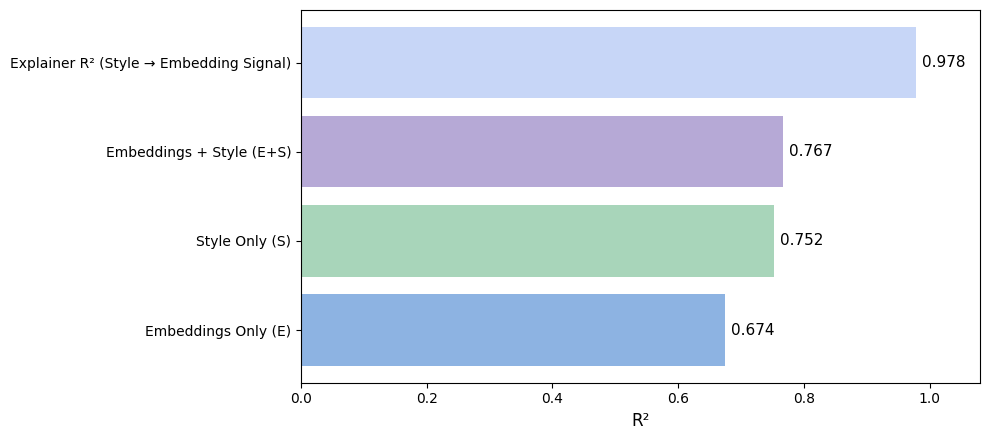

In [7]:
# --- Combined data ---
labels = [
    "Embeddings Only (E)",
    "Style Only (S)",
    "Embeddings + Style (E+S)",
    "Explainer R² (Style → Embedding Signal)",
]
values = [R2_E, R2_S, R2_SE, R2_expl]

colors = ["#8db3e2", "#a8d5ba", "#b6a9d6", "#c7d6f7"]

# Create figure
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.barh(labels, values, color=colors)
ax.set_xlim(0, 1.08)

ax.set_xlabel("R²", fontsize=12)

# Annotate values
for i, v in enumerate(values):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=11)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}redundency.png")
plt.show()

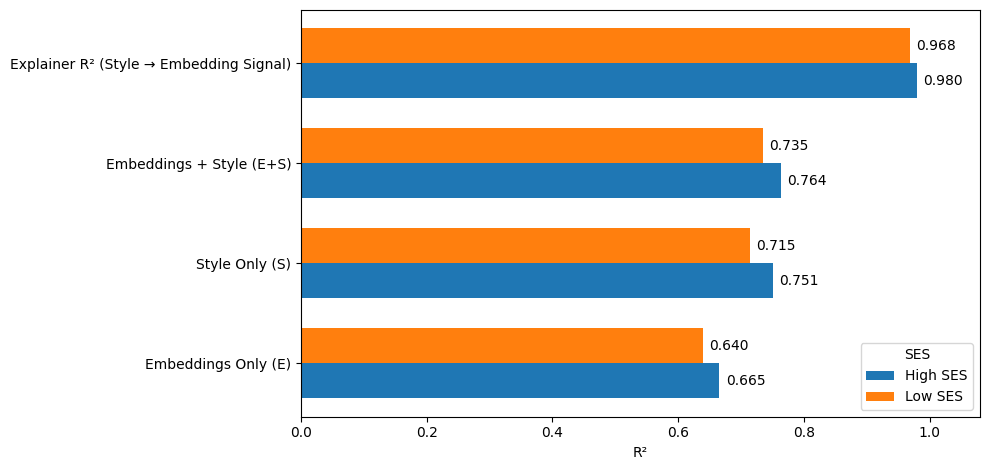

In [8]:
# --- Helper to compute all R² metrics for a given dataframe ---
def compute_r2_bundle(df):
    R2_E = r2_score(df["holistic_essay_score"], df["xgb_oof_pred_x_emb"])
    R2_S = r2_score(df["holistic_essay_score"], df["xgb_oof_pred_x_style"])
    R2_SE = r2_score(df["holistic_essay_score"], df["xgb_oof_pred_x_full"])
    R2_expl = (R2_S + R2_E - R2_SE) / R2_E
    return R2_E, R2_S, R2_SE, R2_expl


# --- Compute metrics per SES ---
R2_E_low, R2_S_low, R2_SE_low, R2_expl_low = compute_r2_bundle(df_low_scorer)
R2_E_high, R2_S_high, R2_SE_high, R2_expl_high = compute_r2_bundle(df_high_scorer)

# --- Plot data ---
labels = [
    "Embeddings Only (E)",
    "Style Only (S)",
    "Embeddings + Style (E+S)",
    "Explainer R² (Style → Embedding Signal)",
]

low_vals  = [R2_E_low,  R2_S_low,  R2_SE_low,  R2_expl_low]
high_vals = [R2_E_high, R2_S_high, R2_SE_high, R2_expl_high]

y = np.arange(len(labels))
bar_h = 0.35

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.barh(
    y - bar_h / 2,
    high_vals,
    height=bar_h,
    color="tab:blue",
    label="High SES"
)
ax.barh(
    y + bar_h / 2,
    low_vals,
    height=bar_h,
    color="tab:orange",
    label="Low SES"
)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0, 1.08)
ax.set_xlabel("R²")

# --- Annotate values ---
for i, (hv, lv) in enumerate(zip(high_vals, low_vals)):
    ax.text(hv + 0.01, i - bar_h/2, f"{hv:.3f}",
            va="center", fontsize=10, clip_on=False)
    ax.text(lv + 0.01, i + bar_h/2, f"{lv:.3f}",
            va="center", fontsize=10, clip_on=False)

ax.legend(title="SES")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}redundency_SES.png")
plt.show()

### Approach B — PID (Williams & Beer)

In [15]:
O = df_all["holistic_essay_score"].to_numpy().astype(float)
U_E = df_all["xgb_oof_pred_x_emb"].to_numpy().astype(float)
U_S = df_all["xgb_oof_pred_x_style"].to_numpy().astype(float)

In [16]:
# STEP 2: Quantile Discretization
n_bins = 5
disc = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")

O_d   = disc.fit_transform(O.reshape(-1,1)).astype(int).squeeze()
U_E_d = disc.fit_transform(U_E.reshape(-1,1)).astype(int).squeeze()
U_S_d = disc.fit_transform(U_S.reshape(-1,1)).astype(int).squeeze()

/Users/pedropertusi/Desktop/contentVsForm/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/pedropertusi/Desktop/contentVsForm/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/pedropertusi/Desktop/contentVsForm/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to n

In [17]:
# 3. Compute mutual information terms

# I(U_E ; O)
I_E = mutual_info_score(U_E_d, O_d)

# I(U_S ; O)
I_S = mutual_info_score(U_S_d, O_d)

# I([U_E, U_S] ; O)
joint_ES = U_E_d * n_bins + U_S_d
I_ES = mutual_info_score(joint_ES, O_d)

In [18]:
# 4. Williams & Beer PID

R = min(I_E, I_S) # redundancy
U_E_unique = I_E - R # unique to embeddings
U_S_unique = I_S - R # unique to style
S = I_ES - (U_E_unique + U_S_unique + R)   # synergy

print("Redundancy:", R)
print("Unique to Embeddings:", U_E_unique)
print("Unique to Style:", U_S_unique)
print("Synergy:", S)

Redundancy: 0.4320251838900582
Unique to Embeddings: 0.0
Unique to Style: 0.07173689556650265
Synergy: 0.03911987289155705


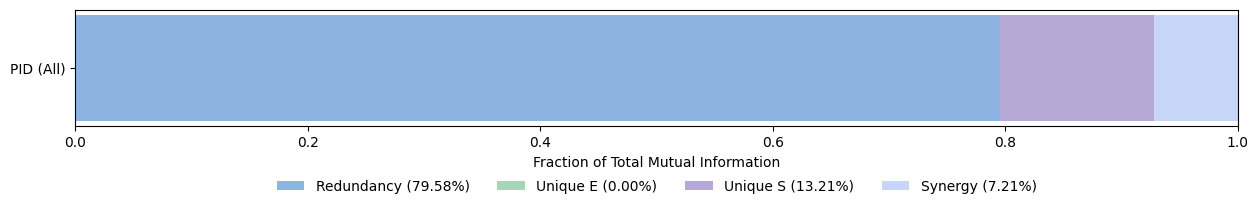

In [19]:
# --- Normalize PID components ---
total_I = R + U_E_unique + U_S_unique + S

R_n   = R / total_I
UE_n  = U_E_unique / total_I
US_n  = U_S_unique / total_I
S_n   = S / total_I

# --- Plot ---
plt.figure(figsize=(15, 2.2))

plt.barh(["PID (All)"], [R_n], color=colors[0], label=f"Redundancy ({R_n:.2%})")
plt.barh(["PID (All)"], [UE_n], left=[R_n], color=colors[1], label=f"Unique E ({UE_n:.2%})")
plt.barh(["PID (All)"], [US_n], left=[R_n + UE_n], color=colors[2], label=f"Unique S ({US_n:.2%})")
plt.barh(
    ["PID (All)"],
    [S_n],
    left=[R_n + UE_n + US_n],
    color=colors[3],
    label=f"Synergy ({S_n:.2%})"
)

plt.xlim(0, 1)
plt.xlabel("Fraction of Total Mutual Information")
# plt.title("Normalized PID Decomposition of Embeddings and Style\nPredicting Essay Score")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=4,
    frameon=False
)

plt.subplots_adjust(bottom=0.35)
plt.savefig(f"{SAVE_DIR}pid_decomposition.png", dpi=300)
plt.show()

In [21]:
def compute_pid(df, n_bins=5):
    O   = df["holistic_essay_score"].to_numpy().astype(float)
    U_E = df["xgb_oof_pred_x_emb"].to_numpy().astype(float)
    U_S = df["xgb_oof_pred_x_style"].to_numpy().astype(float)

    disc = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")

    O_d   = disc.fit_transform(O.reshape(-1,1)).astype(int).squeeze()
    U_E_d = disc.fit_transform(U_E.reshape(-1,1)).astype(int).squeeze()
    U_S_d = disc.fit_transform(U_S.reshape(-1,1)).astype(int).squeeze()

    I_E  = mutual_info_score(U_E_d, O_d)
    I_S  = mutual_info_score(U_S_d, O_d)
    I_ES = mutual_info_score(U_E_d * n_bins + U_S_d, O_d)

    R  = min(I_E, I_S)
    UE = I_E - R
    US = I_S - R
    S  = I_ES - (R + UE + US)

    total = R + UE + US + S

    return np.array([R, UE, US, S]) / total

/Users/pedropertusi/Desktop/contentVsForm/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/pedropertusi/Desktop/contentVsForm/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/pedropertusi/Desktop/contentVsForm/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to n

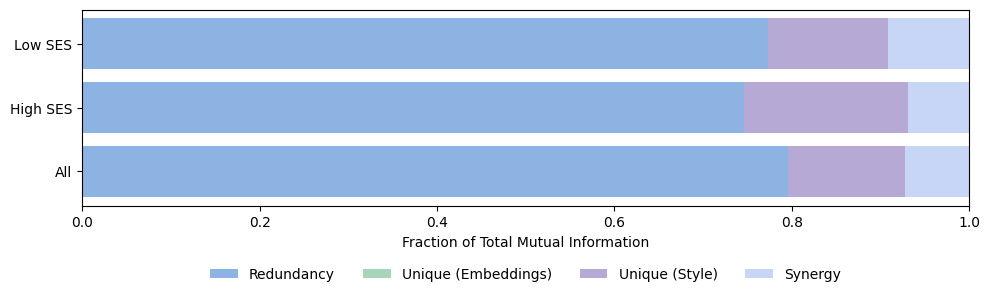

In [22]:
# --- Compute normalized PID for each group ---
pid_all  = compute_pid(df_all)
pid_high = compute_pid(df_high_scorer)
pid_low  = compute_pid(df_low_scorer)

labels = ["All", "High SES", "Low SES"]
pid_stack = np.vstack([pid_all, pid_high, pid_low])

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 3.2))

left = np.zeros(len(labels))

components = [
    "Redundancy",
    "Unique (Embeddings)",
    "Unique (Style)",
    "Synergy",
]

for i, comp in enumerate(components):
    ax.barh(
        labels,
        pid_stack[:, i],
        left=left,
        color=colors[i],   # 👈 EXACT same colors as single-bar PID
        label=comp
    )
    left += pid_stack[:, i]

ax.set_xlim(0, 1)
ax.set_xlabel("Fraction of Total Mutual Information")
# ax.set_title("Normalized PID Decomposition by SES")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}pid_decomposition_by_ses.png")
plt.show()

## Summary of Findings: Approach A & B

### Approach A — Explainer R²

Explainer R² ≈ 0.97

Style features can reconstruct 97% of the embedding model’s score-predictive signal.

Interpretation: Embeddings add almost no linear predictive information beyond what style already provides.

Graph meaning:
The R² comparison shows that the combined model barely improves over style alone, indicating that embedding predictions are essentially stylistic.

### Approach B — PID (Williams & Beer)

Unique information in embeddings = 0.00 bits

Most information is redundant (shared between embeddings and style)

Style retains a small amount of unique information.

Graph meaning:
The PID bar is dominated by redundancy, with no unique-embedding segment, confirming that embeddings contribute no distinctive information about the score.